# Find Optimal K for LDA
Find the optimal number of topics (K) for LDA using **Perplexity** and **Topic Coherence (Cᵥ)** with spaCy preprocessing.

## 1. Installation
Run this cell once to install all required dependencies. You can skip it if they are already installed.

In [12]:
import sys

!{sys.executable} -m pip install \
    notebook \
    ipywidgets \
    numpy \
    matplotlib \
    tqdm \
    scikit-learn \
    spacy \
    gensim

# Download the spaCy English model
!{sys.executable} -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.2 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2. Imports

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
import spacy
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Configuration
Set your input file path and K search range here.

In [2]:
INPUT_FILE = '/content/drive/MyDrive/ColabData/dataset_comsci_math.json' # Path to your JSON dataset file
START_K    = 2 # Starting value for K (min 2)
END_K      = 30 # Ending value for K
STEP_K     = 1 # Step size for K
OUTPUT_DIR = '/content/drive/MyDrive/ColabData' # Directory to save the output plot

## 3. Load Data

In [3]:
if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"File '{INPUT_FILE}' does not exist.")

print(f"Loading data from {INPUT_FILE}...")
with open(INPUT_FILE, 'r', encoding='utf-8') as f:
    data = json.load(f)

texts = [item.get('text', '') for item in data if item.get('text', '').strip()]

if not texts:
    raise ValueError("No text data found in the dataset.")

print(f"Loaded {len(texts)} documents.")

Loading data from /content/drive/MyDrive/ColabData/dataset_comsci_math.json...
Loaded 266 documents.


## 4. spaCy Setup & Custom Stop Words

In [4]:
print("Loading spaCy 'en_core_web_sm'...")
# If not installed, run: python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

academic_stopwords = [
    'finding', 'findings', 'illustrate', 'significant', 'provide', 'provides', 'potential', 'associated', 'effective', 'aspect', 'aspects', 'challenge', 'challenges',
    'paper', 'study', 'research', 'result', 'results', 'method', 'methodology',
    'proposed', 'propose', 'approach', 'based', 'using', 'used', 'use', 'to', 'we', 'source',
    'analysis', 'model', 'system', 'data', 'application', 'new', 'development',
    'performance', 'conclusion', 'abstract', 'introduction', 'work', 'time',
    'significant', 'shown', 'show', 'demonstrate', 'experiment', 'experimental',
    'university', 'department', 'author', 'et', 'al', 'figure', 'table',
    'high', 'low', 'large', 'small', 'different', 'various', 'property', 'properties', 'increase', 'effect', 'activity',
    'structure', 'compound', 'condition', 'quality', 'entry', 'contain', 'parameter', 'observe', 'report', 'present', 'evaluate'
]
for word in academic_stopwords:
    nlp.vocab[word].is_stop = True

print(f"Added {len(academic_stopwords)} academic stop words.")

custom_stopwords = list(set(list(ENGLISH_STOP_WORDS) + academic_stopwords))

def spacy_tokenizer(text):
    if not text:
        return []
    doc = nlp(text)
    return [
        token.lemma_.lower() for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.like_num
        and len(token) > 2
    ]

Loading spaCy 'en_core_web_sm'...
Added 78 academic stop words.


## 5. Vectorize with CountVectorizer (sklearn)

In [5]:
print("Fitting CountVectorizer with spaCy tokenizer...")
vectorizer = CountVectorizer(stop_words=custom_stopwords ,tokenizer=spacy_tokenizer, max_df=0.7, min_df=5)
doc_matrix = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

print(f"Vocabulary size : {len(feature_names)}")
print(f"Document-term matrix shape: {doc_matrix.shape}")

Fitting CountVectorizer with spaCy tokenizer...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Vocabulary size : 625
Document-term matrix shape: (266, 625)


## 6. Tokenize Texts for Gensim Coherence Model

In [6]:
print("Tokenizing texts for Gensim (this may take a while)...")
tokenized_texts = [spacy_tokenizer(text) for text in tqdm(texts, desc="Tokenizing")]
dictionary = Dictionary(tokenized_texts)
print(f"Gensim dictionary size: {len(dictionary)}")

Tokenizing texts for Gensim (this may take a while)...


Tokenizing:   0%|          | 0/266 [00:00<?, ?it/s]

Gensim dictionary size: 3372


## 7. Grid Search over K

In [7]:
start_k = max(2, START_K)
k_values = list(range(start_k, END_K + 1, STEP_K))
perplexity_scores = []
coherence_scores  = []

print(f"Starting grid search for K = {k_values}")

for k in tqdm(k_values, desc="Tuning LDA"):
    # Fit LDA
    lda_model = LatentDirichletAllocation(n_components=k, random_state=42, max_iter=20)
    lda_model.fit(doc_matrix)

    # Perplexity
    perplexity_scores.append(lda_model.perplexity(doc_matrix))

    # Top-10 words per topic
    top_words_per_topic = []
    for topic in lda_model.components_:
        top_features_ind = topic.argsort()[:-10 - 1:-1]
        top_words_per_topic.append([feature_names[i] for i in top_features_ind])

    # Topic Coherence (Cᵥ)
    cm = CoherenceModel(
        topics=top_words_per_topic,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_scores.append(cm.get_coherence())

print("Grid search complete.")

Starting grid search for K = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


Tuning LDA:   0%|          | 0/29 [00:00<?, ?it/s]

Grid search complete.


## 8. Results Summary

In [8]:
best_coherence_k = k_values[int(np.argmax(coherence_scores))]
best_perplexity_k = k_values[int(np.argmin(perplexity_scores))]

print(f"{'K':>5} | {'Perplexity':>12} | {'Coherence (Cᵥ)':>15}")
print("-" * 38)
for k, p, c in zip(k_values, perplexity_scores, coherence_scores):
    print(f"{k:>5} | {p:>12.2f} | {c:>15.4f}")

print(f"\nBest K by Coherence  : {best_coherence_k}")
print(f"Best K by Perplexity : {best_perplexity_k}")

    K |   Perplexity |  Coherence (Cᵥ)
--------------------------------------
    2 |       372.04 |          0.7075
    3 |       364.19 |          0.5559
    4 |       361.89 |          0.6123
    5 |       357.94 |          0.4500
    6 |       356.96 |          0.5905
    7 |       360.06 |          0.4274
    8 |       361.64 |          0.5252
    9 |       361.57 |          0.5250
   10 |       364.59 |          0.5287
   11 |       344.97 |          0.5219
   12 |       353.62 |          0.4602
   13 |       348.09 |          0.5042
   14 |       352.39 |          0.4811
   15 |       347.98 |          0.5235
   16 |       362.66 |          0.4997
   17 |       363.68 |          0.5285
   18 |       360.74 |          0.4949
   19 |       365.55 |          0.4511
   20 |       364.93 |          0.5233
   21 |       361.45 |          0.4722
   22 |       376.83 |          0.4542
   23 |       377.10 |          0.4997
   24 |       377.04 |          0.4844
   25 |       371.30 |   

## 9. Plot: Perplexity vs Topic Coherence

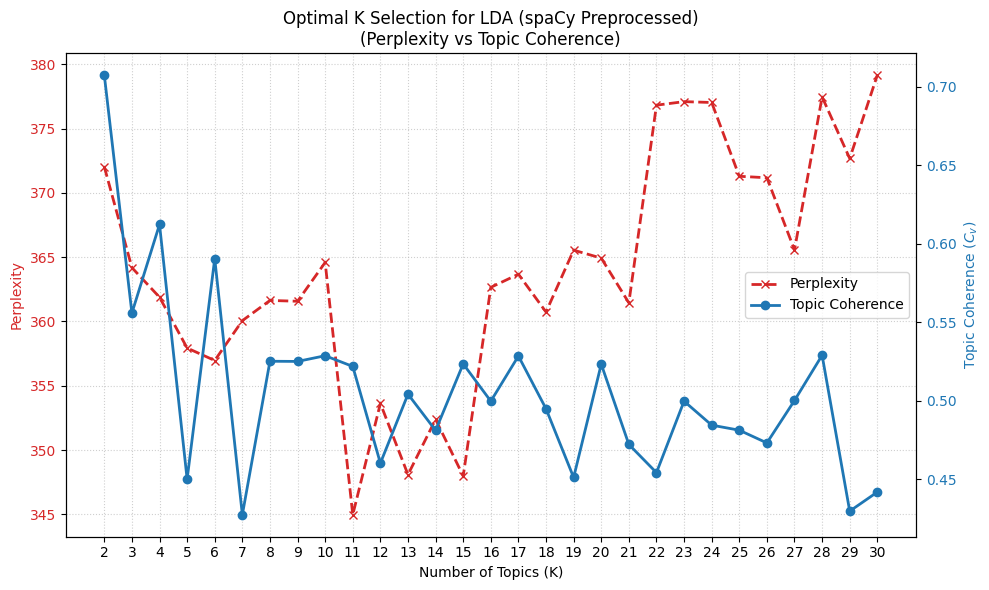

Plot saved to: /content/drive/MyDrive/ColabData/lda_optimal_k_selection.png


In [9]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Perplexity (left axis)
color_perp = 'tab:red'
ax1.set_xlabel('Number of Topics (K)')
ax1.set_ylabel('Perplexity', color=color_perp)
ax1.plot(k_values, perplexity_scores, marker='x', color=color_perp,
         linestyle='--', linewidth=2, label='Perplexity')
ax1.tick_params(axis='y', labelcolor=color_perp)
ax1.set_xticks(k_values)
ax1.grid(True, linestyle=':', alpha=0.6)

# Coherence (right axis)
color_coh = 'tab:blue'
ax2 = ax1.twinx()
ax2.set_ylabel('Topic Coherence ($C_v$)', color=color_coh)
ax2.plot(k_values, coherence_scores, marker='o', color=color_coh,
         linewidth=2, label='Topic Coherence')
ax2.tick_params(axis='y', labelcolor=color_coh)

plt.title('Optimal K Selection for LDA (spaCy Preprocessed)\n(Perplexity vs Topic Coherence)')
fig.tight_layout()

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

output_path = os.path.join(OUTPUT_DIR, 'lda_optimal_k_selection.png')
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to: {output_path}")